# **Day 55: Time Series Analysis - Decomposition, Stationarity, ARIMA and Exponential Smoothing**
*Module 9 - Probabilistic ML, Time Series and Semi-Supervised Learning*

Time series are everywhere: rainfall, river discharge, NDVI profiles, electricity demand, sales, sensor streams. Observations are **ordered and dependent**, so the i.i.d. tools of earlier days need care. Today: the classical statistical toolbox that every forecaster must know and that ML forecasts (Day 56) must beat.

> Time-series analysis studies data ordered in time: trend, seasonality and noise. Stationarity, autocorrelation, ARIMA and exponential smoothing are the classical tools for understanding and forecasting such series.
>
> *Example:* An NDVI series of a crop field shows a seasonal cycle each year; decomposition separates that cycle from a slow multi-year trend.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
warnings.filterwarnings("ignore")
rng = np.random.default_rng(55)

## **1. A Realistic Monthly Series**
Monthly mean NDVI of a district over 15 years: upward trend (irrigation expansion), monsoon seasonality, a drought year, and noise.

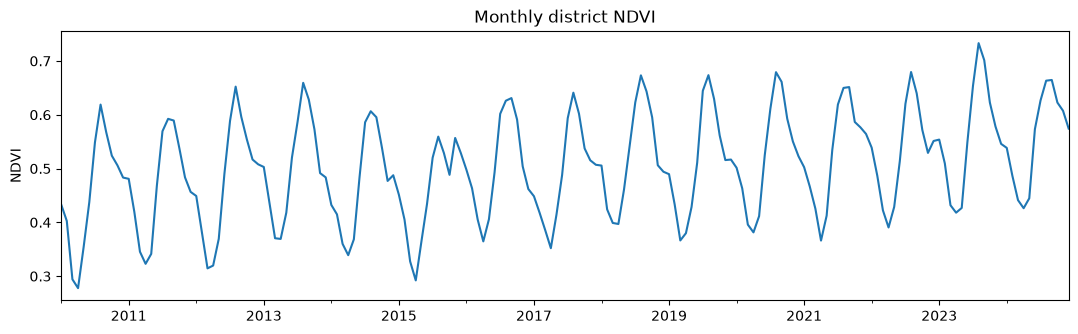

In [2]:
idx = pd.date_range("2010-01", periods=180, freq="MS")
t = np.arange(180)
season = 0.12 * np.sin(2 * np.pi * (t - 5) / 12) + 0.05 * np.sin(4 * np.pi * (t - 5) / 12)
ar_noise = np.zeros(180)
for i in range(1, 180): ar_noise[i] = 0.6 * ar_noise[i - 1] + rng.normal(0, 0.015)
ndvi = pd.Series(0.45 + 0.0006 * t + season + ar_noise, index=idx)
ndvi["2015-06":"2015-10"] -= 0.08                                            # drought
ndvi.plot(figsize=(13, 3.5), title="Monthly district NDVI"); plt.ylabel("NDVI"); plt.show()

## **2. Decomposition**
$y_t = T_t + S_t + R_t$ (additive) or $y_t = T_t\times S_t\times R_t$ (multiplicative, when seasonal amplitude grows with level). **STL** (Seasonal-Trend decomposition using LOESS) is robust to outliers and lets the seasonal pattern evolve.

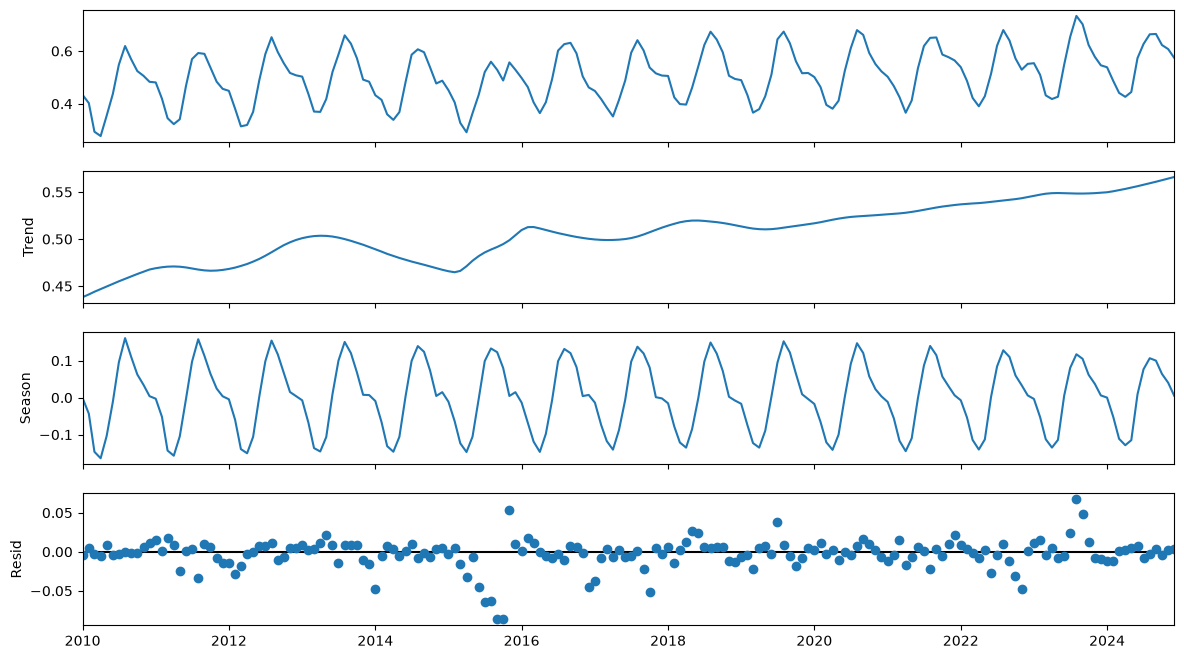

strength of trend 0.74 | strength of seasonality 0.96


In [3]:
stl = STL(ndvi, period=12, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(13, 7); plt.show()
print(f"strength of trend {1 - stl.resid.var() / (stl.trend + stl.resid).var():.2f} | strength of seasonality {1 - stl.resid.var() / (stl.seasonal + stl.resid).var():.2f}")

## **3. Autocorrelation and Partial Autocorrelation**
- **ACF** at lag k: correlation between $y_t$ and $y_{t-k}$.
- **PACF** at lag k: correlation after removing the effect of lags 1..k-1.
Seasonal series show ACF peaks at lags 12, 24, ...

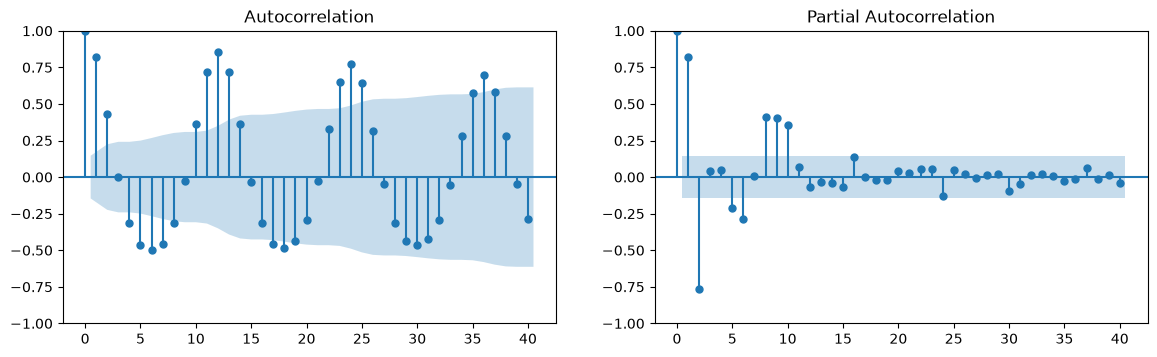

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
plot_acf(ndvi, lags=40, ax=axes[0]); plot_pacf(ndvi, lags=40, ax=axes[1], method="ywm"); plt.show()

## **4. Stationarity**
A **stationary** series has constant mean, variance and autocorrelation over time. ARMA models require it. Remove trend by **differencing** ($y_t - y_{t-1}$) and seasonality by **seasonal differencing** ($y_t - y_{t-12}$).

| Test | Null hypothesis | Want |
|---|---|---|
| ADF (Augmented Dickey-Fuller) | unit root (non-stationary) | small p -> stationary |
| KPSS | stationary | large p -> stationary |

In [5]:
def stationarity_report(s, name):
    adf_p = adfuller(s.dropna(), autolag="AIC")[1]; kpss_p = kpss(s.dropna(), regression="c", nlags="auto")[1]
    print(f"{name:<32} ADF p = {adf_p:.3f} | KPSS p = {kpss_p:.3f}")
stationarity_report(ndvi, "original")
stationarity_report(ndvi.diff(12), "seasonal difference (lag 12)")
stationarity_report(ndvi.diff(12).diff(), "seasonal + first difference")

original                         ADF p = 0.637 | KPSS p = 0.010
seasonal difference (lag 12)     ADF p = 0.001 | KPSS p = 0.100
seasonal + first difference      ADF p = 0.000 | KPSS p = 0.100


## **5. ARIMA and Seasonal ARIMA**
- **AR(p)**: $y_t = c + \sum_{i=1}^p\phi_iy_{t-i} + \varepsilon_t$ (PACF cuts off after lag p)
- **MA(q)**: $y_t = \mu + \varepsilon_t + \sum_{j=1}^q\theta_j\varepsilon_{t-j}$ (ACF cuts off after lag q)
- **ARIMA(p, d, q)**: ARMA on the d-times differenced series
- **SARIMA(p,d,q)(P,D,Q)$_s$**: adds seasonal AR/MA terms at lag $s$

We hold out the last 24 months, select orders by AIC on the training data, and forecast.

In [6]:
train, test = ndvi[:-24], ndvi[-24:]
candidates = [(1, 0, 0), (1, 0, 1), (2, 0, 0), (2, 0, 1)]
seasonal_c = [(0, 1, 1, 12), (1, 1, 0, 12), (1, 1, 1, 12)]
aics = {}
for order in candidates:
    for so in seasonal_c:
        try:
            aics[(order, so)] = SARIMAX(train, order=order, seasonal_order=so, trend="c").fit(disp=False).aic
        except Exception:
            pass
best = min(aics, key=aics.get)
for (order, so), a in sorted(aics.items(), key=lambda kv: kv[1])[:3]:
    print(f"SARIMA{order}x{so}: AIC {a:.1f}")
sarima = SARIMAX(train, order=best[0], seasonal_order=best[1], trend="c").fit(disp=False)
print(sarima.summary().tables[1])

SARIMA(1, 0, 0)x(0, 1, 1, 12): AIC -691.9
SARIMA(2, 0, 0)x(0, 1, 1, 12): AIC -690.5
SARIMA(1, 0, 1)x(0, 1, 1, 12): AIC -689.8


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0021      0.001      4.078      0.000       0.001       0.003
ar.L1          0.6679      0.060     11.086      0.000       0.550       0.786
ma.S.L12      -0.9581      0.424     -2.261      0.024      -1.788      -0.128
sigma2         0.0004      0.000      2.427      0.015     7.3e-05       0.001


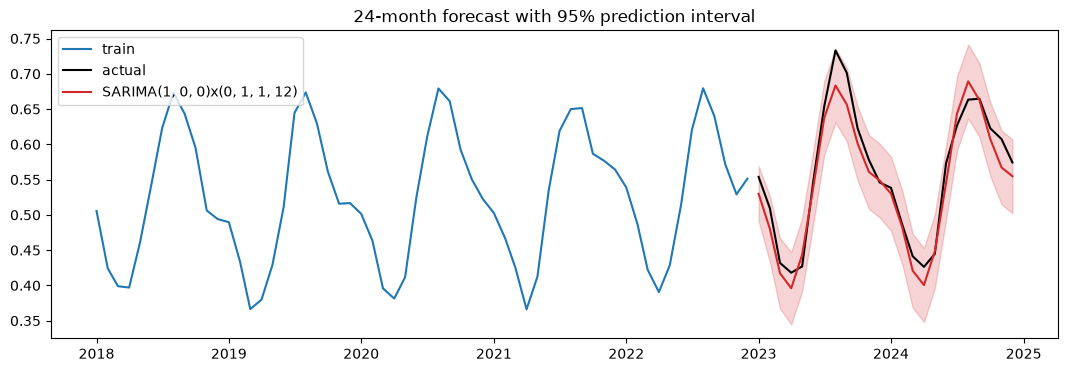

In [7]:
fc = sarima.get_forecast(24); fc_mean = fc.predicted_mean; ci = fc.conf_int(alpha=0.05)
plt.figure(figsize=(13, 4))
plt.plot(train["2018":], label="train"); plt.plot(test, "k", label="actual")
plt.plot(fc_mean, "C3", label=f"SARIMA{best[0]}x{best[1]}"); plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="C3", alpha=0.2)
plt.legend(); plt.title("24-month forecast with 95% prediction interval"); plt.show()

### Residual diagnostics
A good model leaves **white noise** residuals: no autocorrelation (Ljung-Box test), roughly normal.

      lb_stat  lb_pvalue
12  10.457497   0.575891
24  18.524099   0.776870


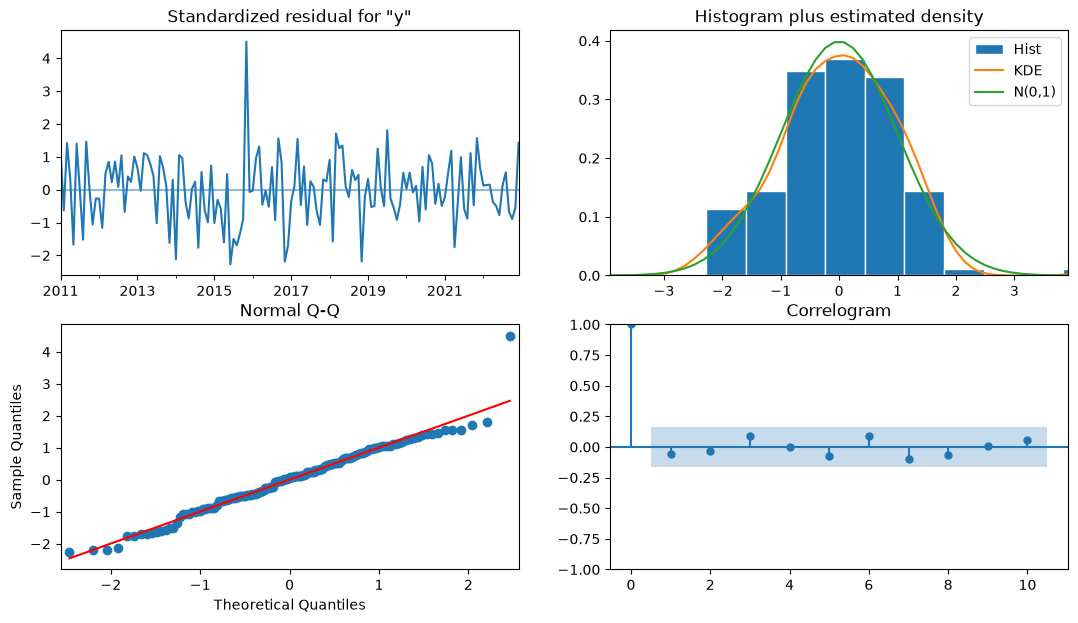

In [8]:
from statsmodels.stats.diagnostic import acorr_ljungbox
print(acorr_ljungbox(sarima.resid[13:], lags=[12, 24]))
fig = sarima.plot_diagnostics(figsize=(13, 7)); plt.show()

## **6. Exponential Smoothing (Holt-Winters / ETS)**
Forecast = weighted average of past observations with exponentially decaying weights; extended with trend (Holt) and seasonality (Winters). Simple, robust, and often hard to beat.

In [9]:
hw = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12, damped_trend=True).fit()
fc_hw = hw.forecast(24)

def mase(y_true, y_pred, y_train, m=12):
    scale = np.mean(np.abs(y_train[m:].values - y_train[:-m].values))        # in-sample seasonal naive error
    return np.mean(np.abs(y_true.values - y_pred.values)) / scale

snaive = pd.Series(train[-12:].values.tolist() * 2, index=test.index)        # seasonal naive: repeat last year
results = {"seasonal naive": snaive, "Holt-Winters (damped)": fc_hw, f"SARIMA{best[0]}x{best[1]}": fc_mean}
pd.DataFrame({k: {"MAE": np.mean(np.abs(test - v)), "RMSE": np.sqrt(np.mean((test - v) ** 2)), "MASE": mase(test, v, train)}
              for k, v in results.items()}).T.round(4)

,MAE,RMSE,MASE
seasonal naive,0.0290,0.0361,0.9496
Holt-Winters (damped),0.0229,0.0266,0.7511
"SARIMA(1, 0, 0)x(0, 1, 1, 12)",0.0199,0.0234,0.6515


**MASE** (mean absolute scaled error, Hyndman & Koehler 2006) divides by the error of the seasonal-naive method: MASE < 1 beats "same month last year". Always include naive baselines.

# **Part 2: Going Deeper - Trend Tests for Climate and Remote Sensing**

Is there a **monotonic trend** in annual NDVI, rainfall or temperature? The non-parametric **Mann-Kendall** test (no normality assumption) and **Sen's slope** (median of pairwise slopes, robust to outliers) are the standard in hydrology, climate and RS trend mapping. With autocorrelated data, use a pre-whitening or variance-corrected version.

In [10]:
from scipy import stats
def mann_kendall(x):
    x = np.asarray(x); n = len(x)
    s = sum(np.sign(x[j] - x[i]) for i in range(n - 1) for j in range(i + 1, n))
    var_s = n * (n - 1) * (2 * n + 5) / 18
    z = (s - np.sign(s)) / np.sqrt(var_s) if s != 0 else 0
    return s, z, 2 * stats.norm.sf(abs(z))

def sens_slope(x):
    x = np.asarray(x); n = len(x)
    return np.median([(x[j] - x[i]) / (j - i) for i in range(n - 1) for j in range(i + 1, n)])

annual = ndvi.resample("YS").mean()
s, z, p = mann_kendall(annual.values)
print(f"Mann-Kendall S = {s:.0f}, Z = {z:.2f}, p = {p:.4f} | Sen's slope = {sens_slope(annual.values) * 10:.4f} NDVI per decade")
kt = stats.kendalltau(np.arange(len(annual)), annual.values); print(f"scipy Kendall tau vs time: tau = {kt.statistic:.3f}, p = {kt.pvalue:.2e}")

Mann-Kendall S = 85, Z = 4.16, p = 0.0000 | Sen's slope = 0.0705 NDVI per decade
scipy Kendall tau vs time: tau = 0.810, p = 2.27e-06


Applying this per pixel over a stack of annual composites gives the greening/browning trend maps common in remote sensing literature (with multiple-testing correction across pixels, Day 11).

## **Practice Problems**
1. Fit a multiplicative Holt-Winters model. Is it better or worse here? Why (is the seasonal amplitude proportional to the level)?
2. Forecast with `ARIMA(train, order=(2, 1, 1))` (no seasonal terms). What happens to the forecast shape?
3. Re-run the trend test on the **monthly** series after removing seasonality with STL (`stl.trend + stl.resid`).
4. *(Advanced)* Implement a rolling-origin evaluation: refit Holt-Winters every 6 months over the last 4 years and report the average 6-step MASE.

multiplicative HW MAE 0.0268 vs additive 0.0229


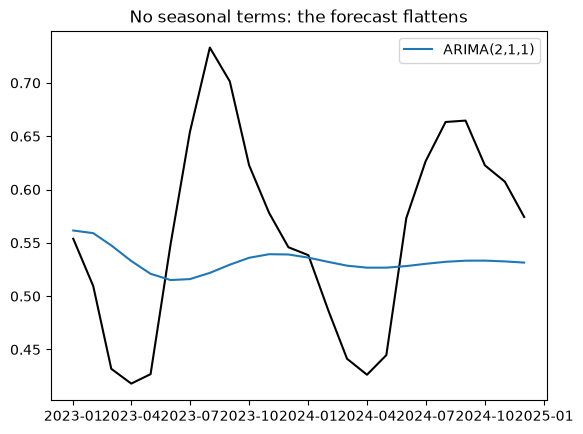

deseasonalised Mann-Kendall p = 1.26e-12, Sen's slope = 0.0658 per decade


rolling-origin 6-step MASE: 0.581 over 8 origins


In [11]:
# Solution 1
hw_m = ExponentialSmoothing(train, trend="add", seasonal="mul", seasonal_periods=12, damped_trend=True).fit()
print(f"multiplicative HW MAE {np.mean(np.abs(test - hw_m.forecast(24))):.4f} vs additive {np.mean(np.abs(test - fc_hw)):.4f}")
# Solution 2
ar = ARIMA(train, order=(2, 1, 1)).fit(); plt.plot(test, "k"); plt.plot(ar.forecast(24), label="ARIMA(2,1,1)"); plt.legend(); plt.title("No seasonal terms: the forecast flattens"); plt.show()
# Solution 3
des = stl.trend + stl.resid; s_, z_, p_ = mann_kendall(des.values[::3])            # every 3rd month to save time
print(f"deseasonalised Mann-Kendall p = {p_:.2e}, Sen's slope = {sens_slope(des.values[::3]) * 4 * 10:.4f} per decade")
# Solution 4
scores = []
for origin in range(len(ndvi) - 48, len(ndvi) - 6 + 1, 6):
    tr_, te_ = ndvi[:origin], ndvi[origin:origin + 6]
    f_ = ExponentialSmoothing(tr_, trend="add", seasonal="add", seasonal_periods=12, damped_trend=True).fit().forecast(6)
    scores.append(mase(te_, f_, tr_))
print(f"rolling-origin 6-step MASE: {np.mean(scores):.3f} over {len(scores)} origins")

## **Key References**
- Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts (free online).
- Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics*, 6(1), 3-73.
- Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679-688.
- Sen, P. K. (1968). Estimates of the regression coefficient based on Kendall's tau. *Journal of the American Statistical Association*, 63(324), 1379-1389.
- Hamed, K. H., & Rao, A. R. (1998). A modified Mann-Kendall trend test for autocorrelated data. *Journal of Hydrology*, 204(1-4), 182-196.